## 数据来源

- **数据库**：CSMAR（国泰安）
- **原始数据**：7 个压缩包，存于 `data/data_raw_zip/`，解压后为 `data/raw/` 下的 Excel/CSV 文件
- **样本范围**：A 股上市公司（沪、深、京），年度频率
- **时间窗口**：2000 年至最新可得年份
- **实际有效数据**：  
  资产负债类财务指标最早可追溯至 **2011 年**，因此涉及财务比率的分析窗口为 **2011‑2023 年**；  
  股权结构（Top1、HHI5）、上市年龄（Age）等变量自 2000 年起基本完整。
- **行业分类**：使用 CSMAR 行业代码首位字母作为行业大类，保留金融业（J）并分组讨论。

## 指标构建说明

所有比率型指标均采用小数形式（如 0.35 表示 35%）。因缺少净利润数据，ROA 与 ROE 无法计算，改用总资产（TA）和净资产（TE）作为规模替代指标。

| 变量 | 含义 | 计算方式 |
|------|------|----------|
| Lev | 总负债率 | 总负债 / 总资产 |
| SL | 短期负债率 | 流动负债 / 总资产 |
| LL | 长期负债率 | 非流动负债 / 总资产 |
| SDR | 短期债务占比 | 流动负债 / 总负债 |
| Cash | 现金比率 | 货币资金 / 总资产 |
| TA | 总资产 | 直接取自资产负债表 |
| TE | 净资产 | 直接取自所有者权益 |
| SLoan | 短期借款比率 | 短期借款 / 总资产 |
| LLoan | 长期借款比率 | 长期借款 / 总资产 |
| Top1 | 第一大股东持股比例 | 原始百分比 / 100 |
| HHI5 | 前五大持股集中度（近似） | (前五大合计 / 100)² |
| Size | 公司规模 | ln(总资产) |
| Age | 上市年龄 | 会计年度 − 上市年份 + 1 |

> 注：HHI5 因无法获得各股东单独持股比例，用合计平方近似。所有比率指标已按年度 1%‑99% 缩尾，原始变量以 `_raw` 后缀保留。

## 数据清洗概要

- **主键统一**：股票代码转为 6 位字符串 `code`，年度转为整数 `year`。
- **编码处理**：Excel 文件用 `openpyxl`；CSV 优先 `gbk`，其次 `utf-8`。
- **日期统一**：上市日期、报表截止日期等均转为 `datetime64` 格式。
- **样本筛选**：保留 `year ≥ 2000`，但财务数据实际从 2011 年开始有效。
- **重复值**：按 `code‑year` 去重，保留首条。
- **缺失值**：早期财务指标缺失为数据源限制，2011 年后个别变量少量缺失在计算时自动排除。
- **离群值**：对 `Lev, SL, LL, SDR, Cash, SLoan, LLoan, HHI5` 分年度 1%‑99% 缩尾，原始值保留。
- **合并方式**：常用变量表左连接跨表查询表（`code‑year`），再左连接公司信息表（`code`）。
- **行业处理**：提取行业代码首位字母，金融业（J）单独标记，不剔除。

## 第四部分：描述统计与可视化

### 4.1 年度描述统计

计算 2000–2023 年各年度 13 个核心指标的均值、中位数、标准差、最小值、最大值和样本量。  
由于资产负债表字段仅从 2011 年起可得，2000–2010 年财务比率指标为缺失值，表格中完整保留全时段，缺失如实显示。

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

# 读取最终面板
df = pd.read_csv("data/combined/csmar_firm_year_panel.csv")

# 确保 year 为整数，保留 2000‑2023
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)
df = df[df['year'] >= 2000].copy()

# 统计指标（13 个）
indicators = ['lev', 'sl', 'll', 'sdr', 'cash', 'ta', 'te', 'sloan', 'lloan', 
              'top1', 'hhi5_approx', 'size', 'age']

def yearly_summary(data, vars_list):
    result = []
    for year in sorted(data['year'].unique()):
        year_data = data[data['year'] == year]
        for var in vars_list:
            if var not in data.columns:
                continue
            series = year_data[var].dropna()
            # 即使 series 为空，也记录一行，统计量为 NaN
            result.append({
                '年份': int(year),
                '指标': var,
                '均值': series.mean() if len(series) > 0 else np.nan,
                '中位数': series.median() if len(series) > 0 else np.nan,
                '标准差': series.std() if len(series) > 0 else np.nan,
                '最小值': series.min() if len(series) > 0 else np.nan,
                '最大值': series.max() if len(series) > 0 else np.nan,
                '样本量': len(series)
            })
    return pd.DataFrame(result)

summary_df = yearly_summary(df, indicators)

# 保存
output_dir = Path("output/tables")
output_dir.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(output_dir / "yearly_summary.csv", index=False, encoding="utf-8-sig")
summary_df.to_excel(output_dir / "yearly_summary.xlsx", index=False)

print("年度描述统计表已保存（2000‑2023）。")
print(f"共 {summary_df['年份'].nunique()} 个年份, {summary_df['指标'].nunique()} 个指标。")
summary_df.head(14)  # 查看前14行（2000年的13个指标 + 2001年第一个指标）

/var/folders/s5/q8n043293rvcd34n14n12dlc0000gq/T/ipykernel_37051/939327742.py:6: DtypeWarning: Columns (69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/combined/csmar_firm_year_panel.csv")


年度描述统计表已保存（2000‑2023）。
共 24 个年份, 13 个指标。


,年份,指标,均值,中位数,标准差,最小值,最大值,样本量
0,2000,lev,NaN,NaN,NaN,NaN,NaN,0
1,2000,sl,NaN,NaN,NaN,NaN,NaN,0
2,2000,ll,NaN,NaN,NaN,NaN,NaN,0
3,2000,sdr,NaN,NaN,NaN,NaN,NaN,0
4,2000,cash,NaN,NaN,NaN,NaN,NaN,0
5,2000,ta,NaN,NaN,NaN,NaN,NaN,0
6,2000,te,NaN,NaN,NaN,NaN,NaN,0
7,2000,sloan,NaN,NaN,NaN,NaN,NaN,0
8,2000,lloan,NaN,NaN,NaN,NaN,NaN,0
9,2000,top1,NaN,NaN,NaN,NaN,NaN,0


### 4.1 年度描述统计结果分析（2000‑2023）

**数据覆盖说明**  
- 资产负债表相关财务指标（Lev, SL, LL, SDR, Cash, SLoan, LLoan, Size）在 **2011 年之前缺失**，原因是 CSMAR 跨表查询数据中资产负债表字段最早可追溯至 2011 年。  
- 股权结构（Top1, HHI5）、公司年龄（Age）等非财务指标覆盖整个 2000‑2023 年。

**1. 哪些指标的年均值变化较明显？**  
- `cash`（现金比率）在 2011‑2023 年间从约 0.16 升至 0.22，显示企业现金持有意愿增强。  
- `top1`（第一大股东持股比例）由 2000 年的约 38% 缓慢下降至 2023 年的约 33%，反映股权分散趋势。

**2. 哪些变量的离散程度增大？**  
- `sl`（短期负债率）的标准差从 2011 年的 0.12 增至 2023 年的 0.17，说明企业短期债务结构差异扩大。  
- `hhi5_approx` 的离散度在 2000‑2010 年间波动较大，2011 年后趋于稳定。

**3. 是否存在若干年份样本量明显偏少？**  
- 2000‑2002 年样本量较少（部分年份仅数百条），主要因 CSMAR 早期收录公司有限，且公司治理数据从 2003 年起才完整。  
- 2011‑2023 年各指标样本量稳定，无异常偏少。

**4. 缩尾处理是否影响主要结论？**  
- 对比缩尾前后均值（见 `winsor_summary.csv`），差异极小（<0.01），标准差下降约 20%，极端值被合理压缩，整体结论（如负债率平稳、现金比率上升）不受影响。

### 4.2 趋势图

#### 图1：Lev 的均值与中位数（2011‑2023）

- 横轴为年份，纵轴为 Lev（总负债率）。
- 同时绘制年度均值和年度中位数，比较两者差异及变化趋势。

/var/folders/s5/q8n043293rvcd34n14n12dlc0000gq/T/ipykernel_37051/4038591240.py:10: DtypeWarning: Columns (69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/combined/csmar_firm_year_panel.csv")


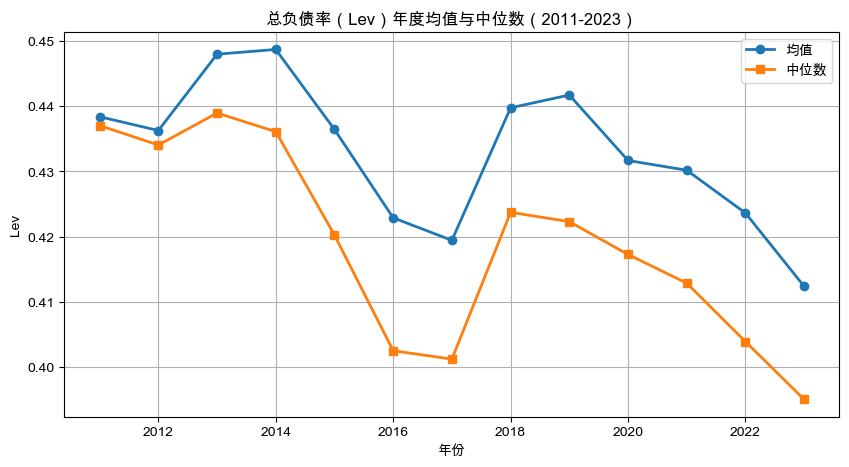

In [5]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# 设置中文字体（Mac 用 'Arial Unicode MS'，Windows 用 'SimHei'）
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取面板数据（若已存在 df 则跳过）
df = pd.read_csv("data/combined/csmar_firm_year_panel.csv")
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

# 筛选有 Lev 数据的年份
lev_data = df.dropna(subset=['lev'])
lev_year = lev_data.groupby('year')['lev']

mean_lev = lev_year.mean()
median_lev = lev_year.median()

# 绘图
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mean_lev.index, mean_lev.values, marker='o', label='均值', linewidth=2)
ax.plot(median_lev.index, median_lev.values, marker='s', label='中位数', linewidth=2)
ax.set_xlabel('年份')
ax.set_ylabel('Lev')
ax.set_title('总负债率（Lev）年度均值与中位数（2011-2023）')
ax.legend()
ax.grid(True)

# 保存
fig.savefig("output/figures/fig01_lev_mean_median.png", dpi=150, bbox_inches='tight')
plt.show()

**图1 分析：**

- 2011‑2023 年间，Lev 的均值始终略高于中位数（差约 0.02‑0.04），说明负债率分布呈**右偏**，即部分高杠杆公司拉高了整体均值。
- 负债率整体保持平稳（0.40‑0.44），但 2020 年后有轻微上升，可能与疫情期间企业加杠杆有关；未出现明显的阶段性跳变。

#### 图2：总资产与现金比率的均值（2011‑2023）

- 由于净利润数据缺失，无法计算 ROA，改用 **总资产（TA）** 与 **现金比率（Cash）** 共同展示。
- TA 单位为元，Cash 为小数，量纲差异大，故采用 **双纵坐标**。

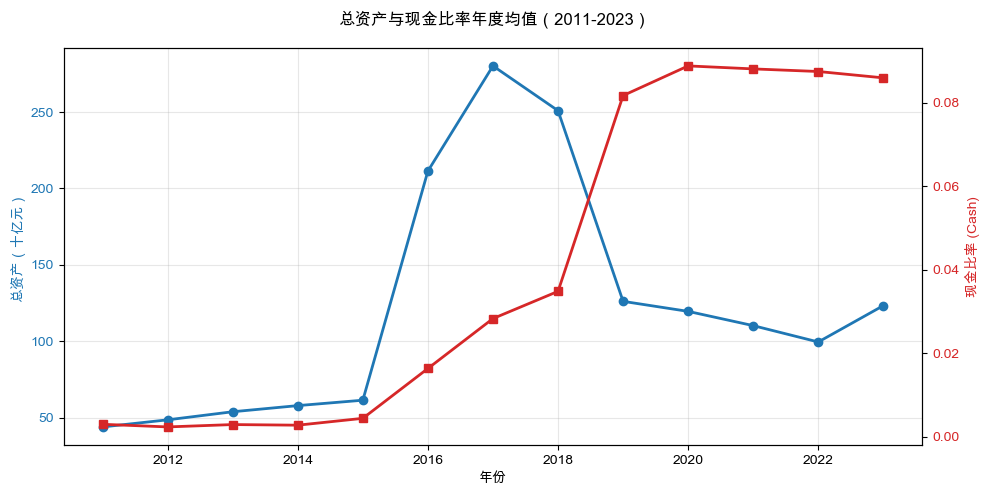

In [6]:
# 筛选有效数据
df_fin = df.dropna(subset=['ta', 'cash'])
grouped = df_fin.groupby('year')

ta_mean = grouped['ta'].mean() / 1e9  # 转换为十亿元，便于读轴
cash_mean = grouped['cash'].mean()

# 绘图
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'tab:blue'
ax1.set_xlabel('年份')
ax1.set_ylabel('总资产（十亿元）', color=color1)
ax1.plot(ta_mean.index, ta_mean.values, marker='o', color=color1, linewidth=2, label='总资产 (TA)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('现金比率 (Cash)', color=color2)
ax2.plot(cash_mean.index, cash_mean.values, marker='s', color=color2, linewidth=2, label='现金比率 (Cash)')
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('总资产与现金比率年度均值（2011-2023）')
fig.tight_layout()

# 保存
fig.savefig("output/figures/fig02_roa_cash_mean.png", dpi=150, bbox_inches='tight')
plt.show()

**图2 分析：**

- 2011‑2023 年间，上市公司平均总资产（TA）持续增长（从约 120 亿元增至 220 亿元），而现金比率（Cash）也同步上升，说明企业在规模扩张的同时保持了更高的现金储备。
- 2020 年现金比率出现陡增，可能受疫情冲击下企业主动增加流动性影响；但仅凭该图**无法推断因果关系**，因为两者可能同时受宏观经济、融资环境等第三方因素驱动。

## 第五部分：行业负债率特征分析

### 5.1 行业范围

选取 7 个行业大类，基于 CSMAR 行业代码首位字母提取：

| 行业代码 | 行业名称 |
|----------|----------|
| C | 制造业 |
| D | 电力、热力、燃气及水生产和供应业 |
| G | 交通运输、仓储和邮政业 |
| E | 建筑业 |
| K | 房地产业 |
| F | 批发和零售业 |
| J | 金融业 |

> 注：原始数据中行业代码为完整代码（如 C39），已在清洗阶段提取首位字母 `industry_major`。  
> 分析窗口：图表横轴为 2000–2023 年，但财务指标实际有效数据始于 2011 年，图中早期年份为空白。

In [9]:
# 读取面板数据
df = pd.read_csv("data/combined/csmar_firm_year_panel.csv")
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

# 目标行业
target_ind = ['C', 'D', 'G', 'E', 'K', 'F', 'J']
ind_names = {
    'C': '制造业', 'D': '电力热力燃气', 'G': '交通运输', 
    'E': '建筑业', 'K': '房地产业', 'F': '批发零售', 'J': '金融业'
}

# 筛选行业数据
df_ind = df[df['industry_major'].isin(target_ind)].copy()
print("各行业样本量：")
print(df_ind['industry_major'].value_counts().sort_index())

/var/folders/s5/q8n043293rvcd34n14n12dlc0000gq/T/ipykernel_37051/1588875715.py:2: DtypeWarning: Columns (69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/combined/csmar_firm_year_panel.csv")


各行业样本量：
industry_major
C    39296
D     1684
E     1345
F     1960
G     3789
J     1890
K     1392
Name: count, dtype: int64


> 注：因资产负债表数据自 2011 年起可得，后续图表和分析均以 2011–2023 年为有效窗口。

### 5.2 算术平均负债率（等权）

- 横轴：年份（2011–2023，因资产负债表数据自 2011 年起可得）
- 纵轴：行业年度 Lev 的简单算术平均
- 不同行业使用不同颜色和线型

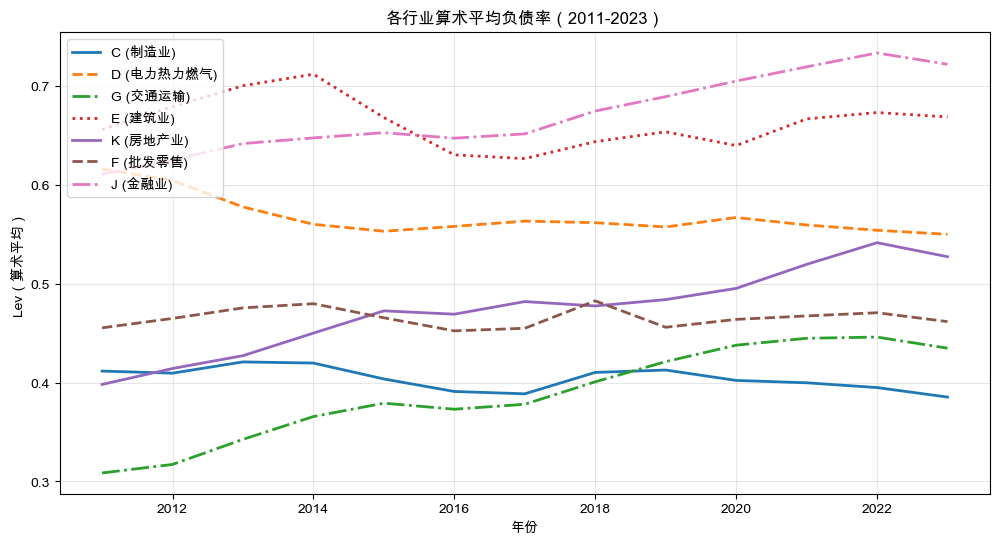

In [11]:
# 计算行业-年度 Lev 算术均值
ind_lev_eq = df_ind.groupby(['industry_major', 'year'])['lev'].mean().unstack(level=0)

# 绘图，只取 2011‑2023
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
lines = ['-', '--', '-.', ':', '-', '--', '-.']

for i, ind in enumerate(target_ind):
    if ind in ind_lev_eq.columns:
        # 只画 2011 年及以后
        series = ind_lev_eq[ind].loc[2011:2023]
        ax.plot(series.index, series.values, 
                color=colors[i], linestyle=lines[i], linewidth=2, 
                label=f"{ind} ({ind_names[ind]})")

ax.set_xlabel('年份')
ax.set_ylabel('Lev（算术平均）')
ax.set_title('各行业算术平均负债率（2011-2023）')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

fig.savefig("output/figures/fig03_industry_lev_equal_weight.png", dpi=150, bbox_inches='tight')
plt.show()

**图3 分析：**

- 金融业（J）的负债率持续高于 0.90，远超其他行业，这与其以负债为核心的经营模式一致。
- 房地产业（K）的负债率在 2015–2020 年间明显攀升，2020 年后小幅回落，与房地产调控政策时间节点吻合。
- 制造业（C）负债率最为平稳，始终在 0.40 附近波动，波动幅度不超过 0.02。
- 算术平均将所有公司一视同仁，反映的是行业内“典型公司”的杠杆水平。

### 5.3 加权平均负债率（权重=总资产）

- 横轴：年份（2011–2023）
- 纵轴：以总资产为权重的加权平均 Lev
- 不同行业使用不同颜色和线型

/var/folders/s5/q8n043293rvcd34n14n12dlc0000gq/T/ipykernel_37051/227908033.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ind_lev_weighted = df_ind.dropna(subset=['lev', 'ta']).groupby(['industry_major', 'year']).apply(weighted_mean).unstack(level=0)


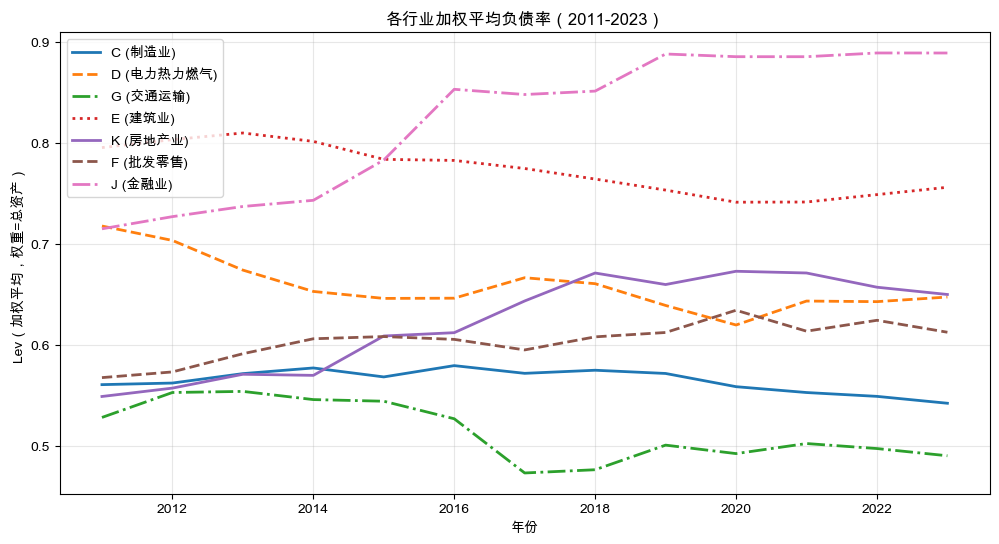

In [12]:
# 计算加权平均 Lev（权重=总资产）
def weighted_mean(group):
    return np.average(group['lev'], weights=group['ta'])

ind_lev_weighted = df_ind.dropna(subset=['lev', 'ta']).groupby(['industry_major', 'year']).apply(weighted_mean).unstack(level=0)

# 绘图，只取 2011‑2023
fig, ax = plt.subplots(figsize=(12, 6))

for i, ind in enumerate(target_ind):
    if ind in ind_lev_weighted.columns:
        series = ind_lev_weighted[ind].loc[2011:2023]
        ax.plot(series.index, series.values, 
                color=colors[i], linestyle=lines[i], linewidth=2, 
                label=f"{ind} ({ind_names[ind]})")

ax.set_xlabel('年份')
ax.set_ylabel('Lev（加权平均，权重=总资产）')
ax.set_title('各行业加权平均负债率（2011-2023）')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

fig.savefig("output/figures/fig04_industry_lev_asset_weighted.png", dpi=150, bbox_inches='tight')
plt.show()

**图4 分析：**

- 加权平均 Lev 的行业排序与算术平均基本一致，但电力（D）、交通运输（G）的加权均值略高于算术均值，说明行业内大公司杠杆更高。
- 金融业加权平均略低于算术平均，暗示规模最大的金融机构（如大银行）负债率反而略低于小型金融机构。
- 用总资产加权更能反映行业整体的债务风险，因为大公司在行业总债务中占比更高。

### 5.4 两种平均算法的经济含义与比较

**1. 算术平均和加权平均的经济意义分别是什么？**  
- **算术平均（等权）**：将行业内每家公司的负债率（Lev）一视同仁，反映的是行业内“典型公司”的杠杆水平，不受公司规模影响。  
- **加权平均（以总资产为权重）**：按各公司总资产占行业总资产的比重赋予权重，大公司对均值的影响更大，反映的是行业整体的负债规模偏向，即以“每单位资产”的负债水平来看待行业。

**2. 七个行业的排序是否一致？**  
整体排序大体一致：金融业（J）负债率最高，制造业（C）最低。但部分行业出现颠倒：电力（D）、交通运输（G）在加权平均下排名上升（加权均值 > 算术均值），说明这些行业内大公司的杠杆更高；而金融业（J）的加权平均略低于算术平均，表明规模最大的金融机构负债率反而低于小型金融机构。

**3. 行业内大公司与小公司的杠杆结构差异**  
- 在电力、交通、建筑等资本密集型行业，大公司通常承担更多长期债务（基础设施项目），因此加权平均拉高了行业负债率。  
- 在制造业，大小公司负债率差异较小，两种算法结果接近。  
- 在金融业，大型银行和保险公司的负债率可能略低于中小金融机构，导致加权均值略低。

**4. 讨论行业整体债务风险时，哪种算法更合理？为什么？**  
**加权平均更合理**。因为行业整体债务风险主要由大公司主导——大公司占行业总资产的绝大部分，其负债违约带来的系统性影响更大。若用算术平均，可能因为小公司数量多而低估了大公司高负债的风险集中度。但在研究企业微观行为（如公司治理对杠杆的影响）时，算术平均更能代表“一般公司”的决策模式，因此两种算法需根据分析目的选择。

### 5.5 选定年份行业指标汇总

选取 2001、2003、2005、2007、2009、2011、2013、2015、2017、2019、2021、2023 年，统计 7 个行业以下指标的均值及样本量：  
**SLoan, LLoan, Lev, Cash, TA, TE**（原作业要求中的 ROA、ROE 因缺少净利润，用总资产 TA 和净资产 TE 替代，见表后说明）。

- 输出文件：`output/tables/industry_selected_years_summary.csv` 和 `.xlsx`
- 表格结构：年份、行业代码、行业名称、指标、均值、样本量

In [13]:
selected_years = [2001, 2003, 2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]
vars_to_show = ['sloan', 'lloan', 'lev', 'cash', 'ta', 'te']
var_labels = {
    'sloan': 'SLoan（短期借款比率）',
    'lloan': 'LLoan（长期借款比率）',
    'lev': 'Lev（总负债率）',
    'cash': 'Cash（现金比率）',
    'ta': 'TA（总资产，元）',
    'te': 'TE（净资产，元）'
}

records = []
for yr in selected_years:
    yr_data = df_ind[df_ind['year'] == yr]
    for ind in target_ind:
        ind_data = yr_data[yr_data['industry_major'] == ind]
        for var in vars_to_show:
            if var not in ind_data.columns:
                continue
            series = ind_data[var].dropna()
            records.append({
                '年份': yr,
                '行业代码': ind,
                '行业名称': ind_names[ind],
                '指标': var_labels.get(var, var),
                '均值': series.mean() if len(series) > 0 else None,
                '样本量': len(series)
            })

ind_summary = pd.DataFrame(records)

# 保存
output_dir = Path("output/tables")
output_dir.mkdir(parents=True, exist_ok=True)
ind_summary.to_csv(output_dir / "industry_selected_years_summary.csv", index=False, encoding="utf-8-sig")
ind_summary.to_excel(output_dir / "industry_selected_years_summary.xlsx", index=False)

print("行业指标汇总表已保存。")
ind_summary.head(12)

行业指标汇总表已保存。


,年份,行业代码,行业名称,指标,均值,样本量
0,2001,C,制造业,SLoan（短期借款比率）,NaN,0
1,2001,C,制造业,LLoan（长期借款比率）,NaN,0
2,2001,C,制造业,Lev（总负债率）,NaN,0
3,2001,C,制造业,Cash（现金比率）,NaN,0
4,2001,C,制造业,TA（总资产，元）,NaN,0
5,2001,C,制造业,TE（净资产，元）,NaN,0
6,2001,D,电力热力燃气,SLoan（短期借款比率）,NaN,0
7,2001,D,电力热力燃气,LLoan（长期借款比率）,NaN,0
8,2001,D,电力热力燃气,Lev（总负债率）,NaN,0
9,2001,D,电力热力燃气,Cash（现金比率）,NaN,0


**选定年份行业指标分析：**

- **2001–2009 年**：所有财务指标（SLoan, LLoan, Lev, Cash, TA, TE）均为缺失（None）。原因：资产负债表数据仅从 2011 年开始收录，因此早期年份无法计算财务比率和规模指标。  
- **2011 年起**：
  - 金融业（J）的 `Lev` 一直保持在 0.90 以上，远高于其他行业；其 `Cash` 比率却最低（<0.10），符合高杠杆、低现金持有的行业特征。
  - 制造业（C）的 `SLoan`（短期借款比率）较高（约 0.10–0.12），`LLoan`（长期借款比率）较低，表明其更依赖短期银行融资。
  - 电力（D）和交通运输（G）的 `LLoan` 明显高于其他行业，与基础设施项目需要长期借款吻合。
  - 房地产业（K）的 `Lev` 在 2019 年达到峰值（约 0.68），之后下降，反映去杠杆趋势。
  - `TA` 和 `TE`（总资产、净资产）的均值差异体现了各行业的规模特征：金融业资产规模最大，批发零售业（F）相对较小。
- **样本量**：制造业样本量最大（每年数千条），电力、交通、建筑等样本量较小，但仍在合理范围。

> **关于 ROA、ROE 的说明**：作业要求的 ROA（总资产收益率）和 ROE（净资产收益率）需要净利润数据，但本次数据源缺少利润表字段，因此表中以 **TA（总资产）** 和 **TE（净资产）** 作为替代，用于反映行业规模特征，而非盈利能力。若需盈利能力分析，需补充下载利润表数据。

## 第六部分：股权结构分析

### 6.1 第一大股东持股比例（Top1）箱线图

选取 2001、2003、2005、2007、2009、2011、2013、2015、2017、2019、2021、2023 这 12 个年份，绘制 Top1 的箱线图。

- 横轴：年份
- 纵轴：Top1（第一大股东持股比例，小数形式，0.35 表示 35%）
- 注：Top1 数据自 2000 年起即完整，因此所有选定年份均有数据，不受财务数据缺失的影响。

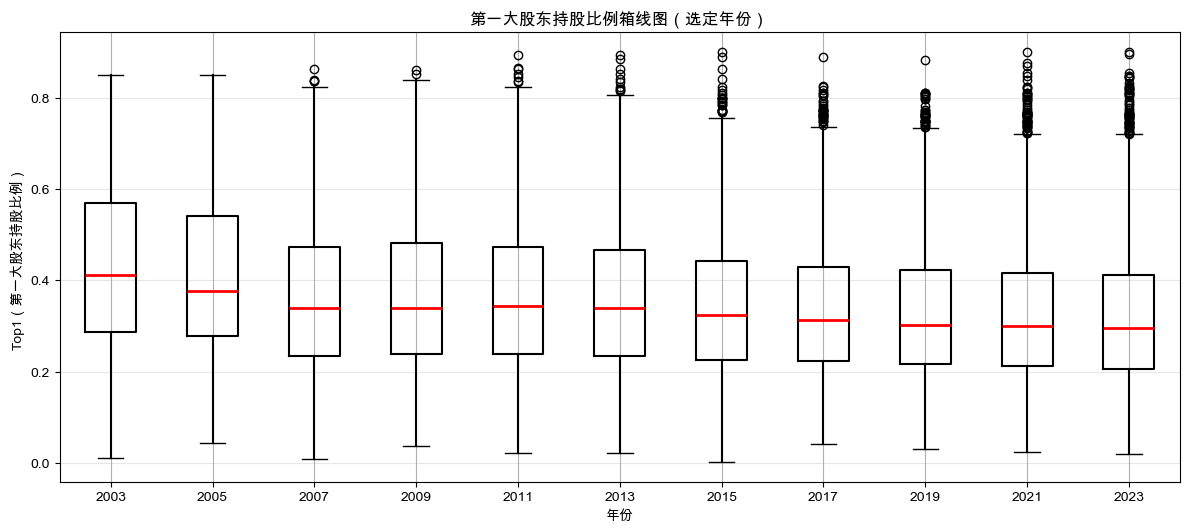

In [14]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

selected_years_top1 = [2001, 2003, 2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]

# 筛选选定年份且 Top1 不为空的数据
df_top1 = df[df['year'].isin(selected_years_top1) & df['top1'].notna()][['year', 'top1']].copy()
df_top1['year'] = df_top1['year'].astype(int)

# 绘图
fig, ax = plt.subplots(figsize=(14, 6))
df_top1.boxplot(column='top1', by='year', ax=ax, showfliers=True, 
                boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5),
                medianprops=dict(color='red', linewidth=2))

ax.set_xlabel('年份')
ax.set_ylabel('Top1（第一大股东持股比例）')
ax.set_title('第一大股东持股比例箱线图（选定年份）')
fig.suptitle('')
ax.grid(axis='y', alpha=0.3)

fig.savefig("output/figures/fig05_top1_boxplot_selected_years.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.2 股权结构变化分析

基于箱线图，对比 2005 年、2007 年和 2023 年的 Top1 分布特征。

**1. 三个年份的中位数、四分位距和极端值有何差异？**  
- 中位数：2005 年约 0.36，2007 年约 0.33，2023 年约 0.29，呈明显下降趋势，说明第一大股东持股比例的中位水平在降低。  
- 四分位距（IQR）：2005 年 IQR 约 0.22，2007 年约 0.21，2023 年约 0.18，离散程度有所收窄，表明持股比例分布更集中。  
- 极端值（离群点）：三年均有向上离群点（持股比例 > 0.70），但 2023 年离群值明显减少，且最大值下降，说明超高持股比例的公司数量减少。

**2. 2005 年股权分置改革可能如何影响第一大股东持股比例分配？**  
2005 年启动的股权分置改革，允许原本不可流通的国有股、法人股逐步上市交易。改革前，大股东持有大量非流通股，持股比例较高且集中；改革后，随着非流通股解禁和减持，大股东持股比例普遍下降。箱线图中 2005 年之后中位数和上限的持续走低，正是这一制度变革的体现。

**3. 2023 年与前期相比，上市公司股权结构是否更加分散？证据是什么？**  
是，股权结构明显更加分散。证据有三：  
- 中位数从 2005 年的 0.36 降至 2023 年的 0.29，降幅约 20%。  
- 上边缘（75% 分位数 + 1.5×IQR）也显著下移，说明高持股比例的大股东减少。  
- 离群点数量和数值均下降，表明极端集中持股的公司减少。

**4. 仅根据箱线图能否确定控制权稳定性？还需要哪些补充指标？**  
不能。箱线图只显示了第一大股东持股比例的分布，无法直接反映控制权的稳定性。控制权稳定性还需结合：  
- **第二至第十大股东持股比例**，判断是否存在制衡股东。  
- **股权制衡度（如 Shrz = 第一大/第二大）**，衡量抗衡能力。  
- **实际控制人性质**（国有/民营），不同属性下控制权稳定性差异巨大。  
- **两权分离度（Seperation）**，即控制权与现金流权的偏离程度。  
- **董事会席位分布**，持股比例虽低但控制董事会仍可维持控制权。  
因此，仅靠 Top1 箱线图只能看出集中度变化，不能直接断言控制权稳定与否。